# Preliminary

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from alphagenome import colab_utils
from alphagenome.data import gene_annotation, genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.interpretation import ism
from alphagenome.models import dna_client, variant_scorers
from alphagenome.visualization import plot_components
from dotenv import load_dotenv

from dgipy import get_interactions

load_dotenv()

/Users/rmb015/Documents/GitHub/dgipy/.venv/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.27.2 is exactly one major version older than the runtime version 6.31.1 at alphagenome/protos/dna_model.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Users/rmb015/Documents/GitHub/dgipy/.venv/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.27.2 is exactly one major version older than the runtime version 6.31.1 at alphagenome/protos/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Users/rmb015/Documents/GitHub/dgipy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as note

True

In [2]:
gtf = pd.read_feather(
    "https://storage.googleapis.com/alphagenome/reference/gencode/hg38/gencode.v46.annotation.gtf.gz.feather"
)

In [3]:
# Filtering
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_longest_transcript(gtf_transcripts)

# Extracting
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

output_attr_map = {
    dna_client.OutputType.ATAC: "atac",
    dna_client.OutputType.CAGE: "cage",
    dna_client.OutputType.DNASE: "dnase",
    dna_client.OutputType.RNA_SEQ: "rna_seq",
    dna_client.OutputType.CHIP_HISTONE: "chip_histone",
    dna_client.OutputType.CHIP_TF: "chip_tf",
    dna_client.OutputType.SPLICE_SITES: "splice_sites",
    dna_client.OutputType.SPLICE_SITE_USAGE: "splice_site_usage",
    dna_client.OutputType.SPLICE_JUNCTIONS: "splice_junctions",
    dna_client.OutputType.CONTACT_MAPS: "contact_maps",
    dna_client.OutputType.PROCAP: "procap",
}

# Basic Functions

In [4]:
def get_dna_model():
    api_key = os.getenv("ALPHA_GENOME_API_KEY")
    if not api_key:
        raise EnvironmentError("ALPHA_GENOME_API_KEY not found in environment variables.")
    return dna_client.create(api_key)

def get_gtf_gene_interval(gene: str):
    interval = gene_annotation.get_gene_interval(gtf, gene_symbol=gene)
    return interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

def model_predict(gene: str, output_type: dna_client.OutputType):
    dna_model = get_dna_model()
    interval = get_gtf_gene_interval(gene)

    output = dna_model.predict_interval(
        interval=interval,
        requested_outputs=[output_type],
        ontology_terms=['UBERON:0001114'],
    )

    longest_transcripts = transcript_extractor.extract(interval)
    print(f"Extracted {len(longest_transcripts)} transcripts in this interval.")

    output_attr = output_attr_map.get(output_type)
    if output_attr is None:
        raise ValueError(f"No mapping found for output type: {output_type}")

    output_data = getattr(output, output_attr)

    plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(longest_transcripts),
            plot_components.Tracks(output_data),
        ],
        interval=output_data.interval,
    )

    plt.show()

    return output


In [5]:
[output.name for output in dna_client.OutputType]

['ATAC',
 'CAGE',
 'DNASE',
 'RNA_SEQ',
 'CHIP_HISTONE',
 'CHIP_TF',
 'SPLICE_SITES',
 'SPLICE_SITE_USAGE',
 'SPLICE_JUNCTIONS',
 'CONTACT_MAPS',
 'PROCAP']

Extracted 9 transcripts in this interval.


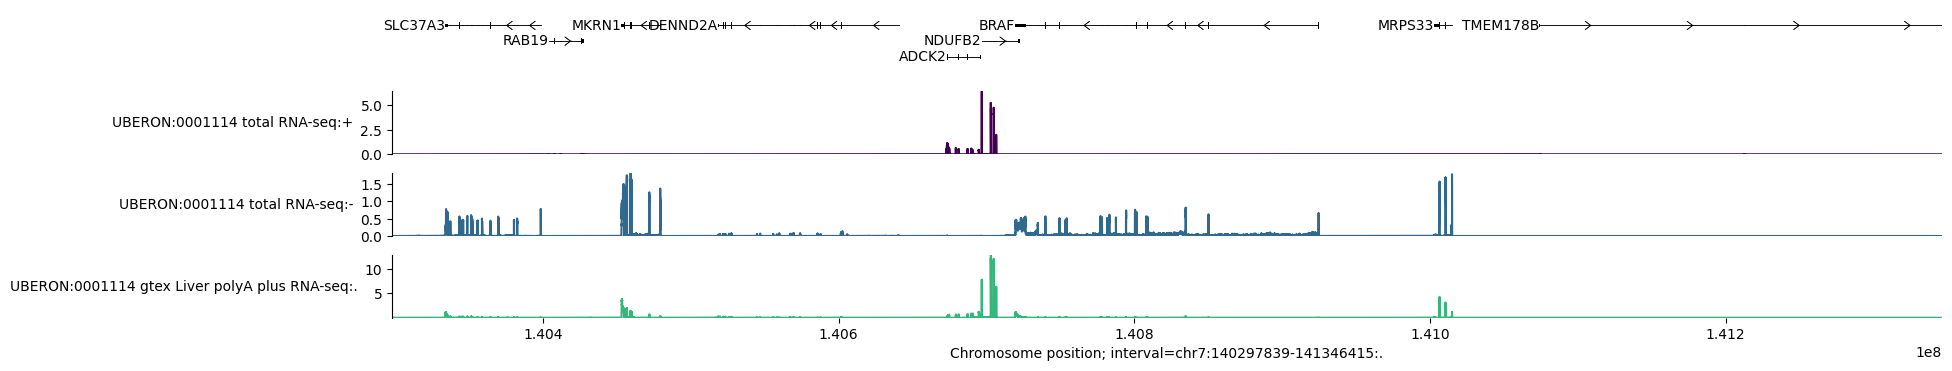

In [6]:
output = model_predict("BRAF", dna_client.OutputType.RNA_SEQ)

# Variant Functions

In [7]:
def create_variant_from_gene(gene: str):
    interval = get_gtf_gene_interval(gene)
    print(f"Gene interval for {gene}:")
    print(f"Chromosome: {interval.chromosome}")
    print(f"Start: {interval.start}")
    print(f"End: {interval.end}")

    position = int(input(f"Enter variant position (between {interval.start} and {interval.end}): "))
    ref_base = input("Enter reference base: ")
    alt_base = input("Enter alternate base: ")

    print(f"Creating variant at {interval.chromosome}:{position} {ref_base}>{alt_base}")
    variant = genome.Variant(
        chromosome=interval.chromosome,
        position=position,
        reference_bases=ref_base,
        alternate_bases=alt_base,
    )
    return variant

def predict_variant_from_gene(gene: str):
    variant = create_variant_from_gene(gene)
    interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)
    dna_model = get_dna_model()

    variant_output = dna_model.predict_variant(
        interval=interval,
        variant=variant,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=['UBERON:0001157'],
    )

    longest_transcripts = transcript_extractor.extract(interval)
    plot_components.plot(
        [
            plot_components.TranscriptAnnotation(longest_transcripts),
            plot_components.OverlaidTracks(
                tdata={
                    "REF": variant_output.reference.rna_seq,
                    "ALT": variant_output.alternate.rna_seq,
                },
                colors={'REF': 'dimgrey', 'ALT': 'red'},
            ),
        ],
        interval=variant_output.reference.rna_seq.interval.resize(2**15),
        # Annotate the location of the variant as a vertical line.
        annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
    )
    plt.show()

    variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ']

    variant_scores = dna_model.score_variant(
        interval=interval, variant=variant, variant_scorers=[variant_scorer]
    )

    return variant_scores

Gene interval for BRAF:
Chromosome: chr7
Start: 140297839
End: 141346415
Creating variant at chr7:140297900 A>C


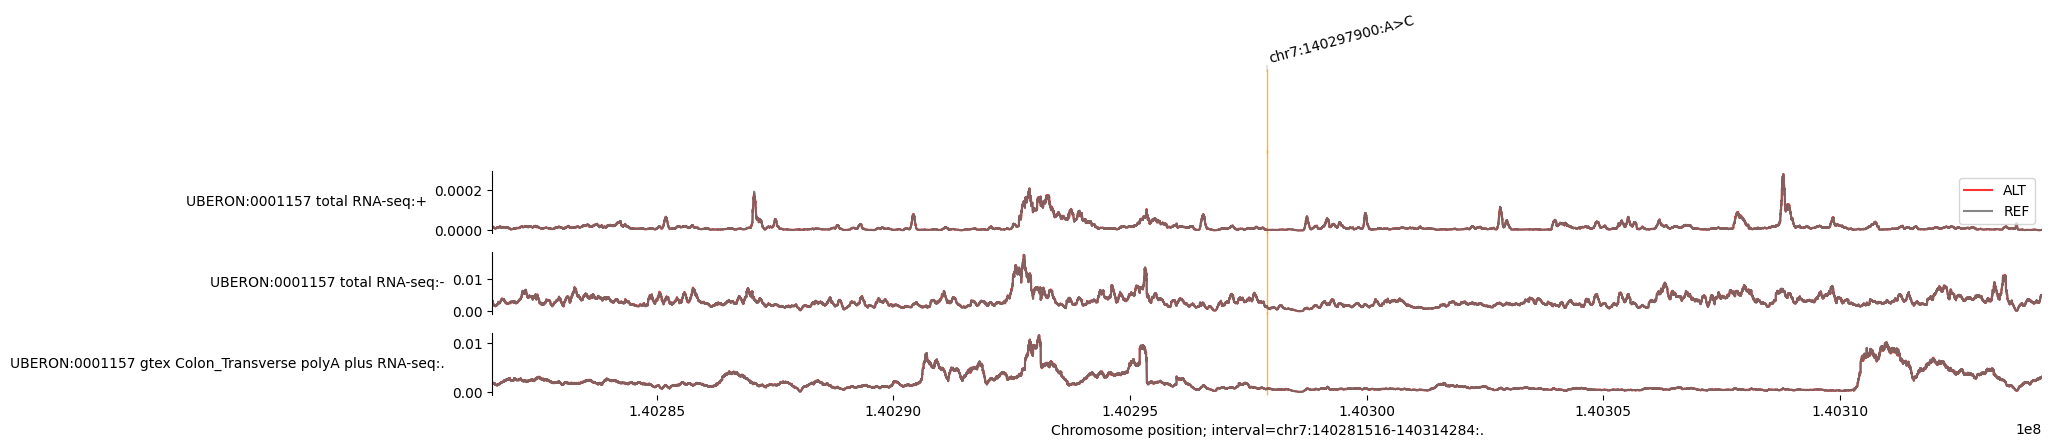

In [8]:
variant_scores = predict_variant_from_gene("BRAF") # 140297900


In [9]:
variant_scores = variant_scores[0]
variant_scorers.tidy_scores([variant_scores], match_gene_strand=True)

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,gtex_tissue,raw_score,quantile_score
0,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000006459,KDM7A,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000047 polyA plus RNA-seq,-,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,,0.000626,0.511872
1,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000006459,KDM7A,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000062 total RNA-seq,-,total RNA-seq,CL:0000062,osteoblast,primary_cell,,0.000381,0.494645
2,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000006459,KDM7A,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000084 polyA plus RNA-seq,-,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,,-0.000163,-0.270000
3,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000006459,KDM7A,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000084 total RNA-seq,-,total RNA-seq,CL:0000084,T-cell,primary_cell,,-0.000042,-0.148854
4,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000006459,KDM7A,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000115 total RNA-seq,-,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,,-0.000002,-0.011535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9895,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000289788,ENSG00000289788,lncRNA,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018115 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018115,left renal pelvis,tissue,,-0.001212,-0.668219
9896,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000289788,ENSG00000289788,lncRNA,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018116 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018116,right renal pelvis,tissue,,-0.001033,-0.613947
9897,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000289788,ENSG00000289788,lncRNA,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018117 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018117,left renal cortex interstitium,tissue,,-0.000569,-0.440600
9898,chr7:140297900:A>C,chr7:139773612-140822188:.,ENSG00000289788,ENSG00000289788,lncRNA,+,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018118 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018118,right renal cortex interstitium,tissue,,-0.001475,-0.721776
